# 🌤️ Weather Simulation & Statistical Analysis
**Course:** Simulation and Modeling Lab (CSE 413)

| Member | Section | Task |
|--------|---------|------|
| Member 1 | Setup & Simulation | Generate weather data |
| Member 2 | One-Sample t-Test | Test against normal temperature |
| Member 3 | Two-Sample t-Test | Compare two cities |
| Member 4 | Chi-Square + Animation | Category check & animated chart |

---
**Project Idea:** We simulate 30 days of temperature data for two cities — Dhaka and Cox's Bazar — and use statistical tests to analyze and compare them.

---
# 👤 Member 1 — Setup & Simulation
### Simulate 30 days of temperature data for two cities

Dhaka     — Mean: 31.44°C,  Std: 2.65
Cox's Bazar— Mean: 26.52°C, Std: 3.66


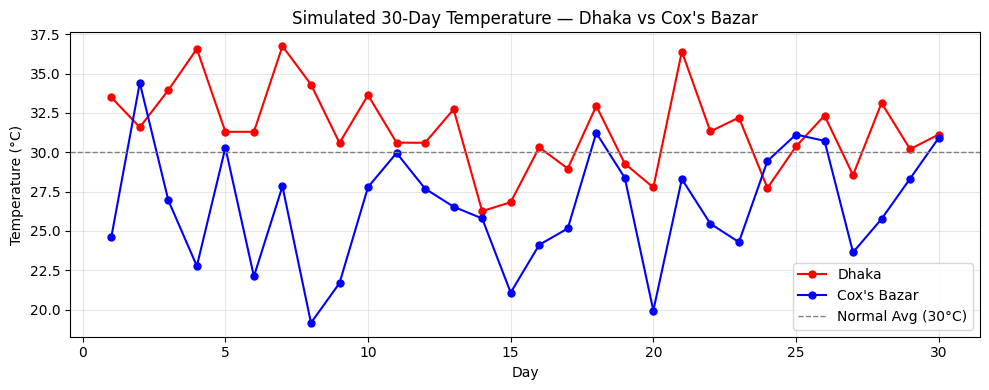

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

np.random.seed(42)

# Simulate 30 days of temperature (in Celsius) using normal distribution
dhaka     = np.random.normal(loc=32, scale=3, size=30)  # mean=32, std=3
coxsbazar = np.random.normal(loc=27, scale=4, size=30)  # mean=27, std=4
days      = np.arange(1, 31)

print("Dhaka     — Mean: {:.2f}°C,  Std: {:.2f}".format(dhaka.mean(), dhaka.std()))
print("Cox's Bazar— Mean: {:.2f}°C, Std: {:.2f}".format(coxsbazar.mean(), coxsbazar.std()))

# Plot the simulated data
plt.figure(figsize=(10, 4))
plt.plot(days, dhaka,     'r-o', markersize=5, label="Dhaka")
plt.plot(days, coxsbazar, 'b-o', markersize=5, label="Cox's Bazar")
plt.axhline(y=30, color='gray', linestyle='--', linewidth=1, label='Normal Avg (30°C)')
plt.xlabel("Day")
plt.ylabel("Temperature (°C)")
plt.title("Simulated 30-Day Temperature — Dhaka vs Cox's Bazar")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 👤 Member 2 — One-Sample t-Test
### Is Dhaka's average temperature significantly different from the national average of 30°C?

- **H₀:** Mean temperature of Dhaka = 30°C  
- **H₁:** Mean temperature of Dhaka ≠ 30°C

======== ONE-SAMPLE t-TEST ========
Sample Mean (Dhaka) : 31.44°C
Hypothesized Mean   : 30°C
t-Statistic         : 2.9122
Degrees of Freedom  : 29
p-Value             : 0.0068
95% Confidence Interval: [30.43, 32.44]
-----------------------------------
RESULT: Reject H0 — Dhaka is significantly hotter than 30°C


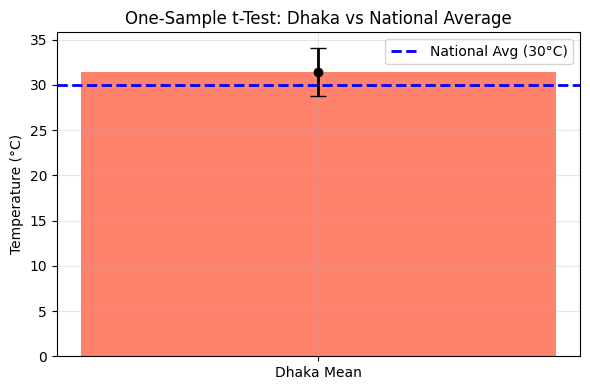

In [ ]:
national_avg = 30  # Hypothesized mean (°C)
alpha = 0.05

t_stat, p_value = stats.ttest_1samp(dhaka, national_avg)
ci = stats.t.interval(0.95, df=len(dhaka)-1,
                      loc=np.mean(dhaka),
                      scale=stats.sem(dhaka))

print("======== ONE-SAMPLE t-TEST ========")
print("Sample Mean (Dhaka) : {:.2f}°C".format(np.mean(dhaka)))
print("Hypothesized Mean   : {}°C".format(national_avg))
print("t-Statistic         : {:.4f}".format(t_stat))
print("Degrees of Freedom  : {}".format(len(dhaka) - 1))
print("p-Value             : {:.4f}".format(p_value))
print("95% Confidence Interval: [{:.2f}, {:.2f}]".format(ci[0], ci[1]))
print("-----------------------------------")
if p_value < alpha:
    print("RESULT: Reject H0 — Dhaka is significantly hotter than 30°C")
else:
    print("RESULT: Fail to Reject H0 — No significant difference from 30°C")

# Visualization
plt.figure(figsize=(6, 4))
plt.bar(["Dhaka Mean"], [np.mean(dhaka)], color='tomato', alpha=0.8, width=0.4)
plt.errorbar(["Dhaka Mean"], [np.mean(dhaka)],
             yerr=np.std(dhaka), fmt='ko', capsize=6, linewidth=2)
plt.axhline(y=national_avg, color='blue', linestyle='--',
            linewidth=2, label='National Avg (30°C)')
plt.ylabel("Temperature (°C)")
plt.title("One-Sample t-Test: Dhaka vs National Average")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 👤 Member 3 — Two-Sample t-Test
### Is Dhaka significantly hotter than Cox's Bazar?

- **H₀:** Mean temp of Dhaka = Mean temp of Cox's Bazar  
- **H₁:** Means are significantly different

======== TWO-SAMPLE t-TEST ========
Dhaka Mean       : 31.44°C
Cox's Bazar Mean : 26.52°C
Mean Difference  : 4.92°C
t-Statistic      : 5.8583
Degrees of Freedom: 58
p-Value          : 0.0000
95% CI (diff)    : [3.24, 6.60]
-----------------------------------
RESULT: Reject H0 — Dhaka is significantly hotter than Cox's Bazar


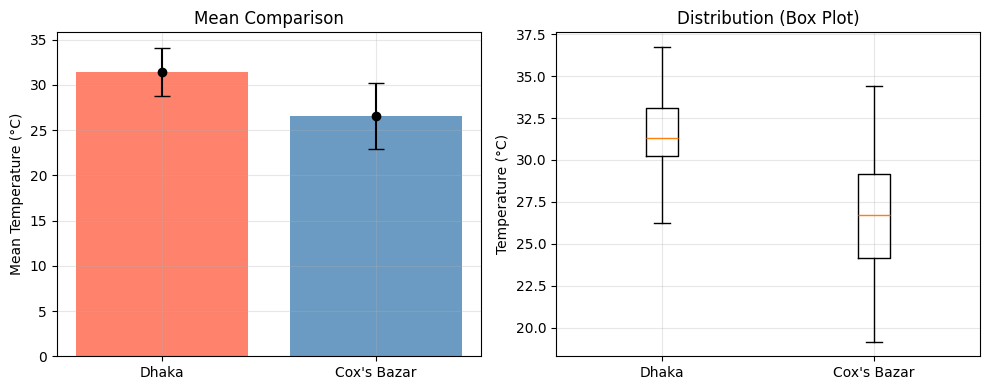

In [ ]:
t_stat2, p_value2 = stats.ttest_ind(dhaka, coxsbazar, equal_var=True)

# Confidence interval for the difference
mean_diff = np.mean(dhaka) - np.mean(coxsbazar)
n1, n2 = len(dhaka), len(coxsbazar)
s1 = np.var(dhaka, ddof=1)
s2 = np.var(coxsbazar, ddof=1)
sp = ((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2)
se = np.sqrt(sp * (1/n1 + 1/n2))
df2 = n1 + n2 - 2
ci2 = stats.t.interval(0.95, df2, loc=mean_diff, scale=se)

print("======== TWO-SAMPLE t-TEST ========")
print("Dhaka Mean       : {:.2f}°C".format(np.mean(dhaka)))
print("Cox's Bazar Mean : {:.2f}°C".format(np.mean(coxsbazar)))
print("Mean Difference  : {:.2f}°C".format(mean_diff))
print("t-Statistic      : {:.4f}".format(t_stat2))
print("Degrees of Freedom: {}".format(df2))
print("p-Value          : {:.4f}".format(p_value2))
print("95% CI (diff)    : [{:.2f}, {:.2f}]".format(ci2[0], ci2[1]))
print("-----------------------------------")
if p_value2 < 0.05:
    print("RESULT: Reject H0 — Dhaka is significantly hotter than Cox's Bazar")
else:
    print("RESULT: Fail to Reject H0 — No significant difference between cities")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Dhaka", "Cox's Bazar"],
            [np.mean(dhaka), np.mean(coxsbazar)],
            color=['tomato', 'steelblue'], alpha=0.8)
axes[0].errorbar(["Dhaka", "Cox's Bazar"],
                 [np.mean(dhaka), np.mean(coxsbazar)],
                 yerr=[np.std(dhaka), np.std(coxsbazar)],
                 fmt='ko', capsize=6)
axes[0].set_ylabel("Mean Temperature (°C)")
axes[0].set_title("Mean Comparison")
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([dhaka, coxsbazar], tick_labels=["Dhaka", "Cox's Bazar"])
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_title("Distribution (Box Plot)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Member 4 — shimanto -> Chi-Square Test + Animation
### Part A: Are temperature categories evenly distributed in Dhaka?

We group days into 3 categories: **Cool (<28°C)**, **Warm (28–32°C)**, **Hot (>32°C)**

- **H₀:** All 3 categories occur equally (uniform distribution)  
- **H₁:** Some categories appear significantly more often

======== CHI-SQUARE TEST ========
Category    Observed   Expected
---------------------------------
Cool (<28)         4       10.0
Warm (28-32)      14       10.0
Hot  (>32)        12       10.0
---------------------------------
Chi-Square Statistic : 5.6000
Degrees of Freedom   : 2
Critical Value (0.05): 5.9915
p-Value              : 0.0608
---------------------------------
RESULT: Fail to Reject H0 — Distribution is fairly uniform


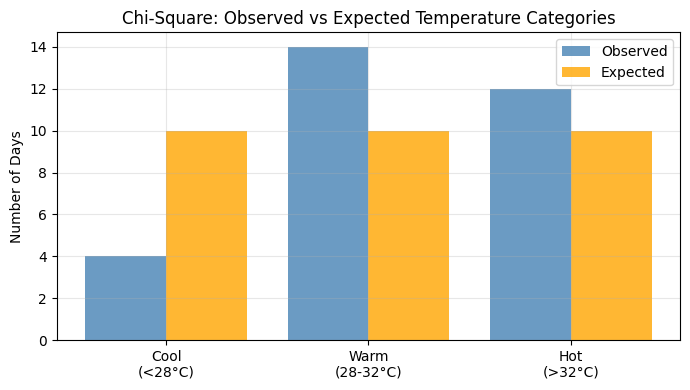

In [ ]:
# --- Chi-Square Test ---
def categorize(temps):
    result = []
    for t in temps:
        if   t < 28: result.append('Cool')
        elif t < 32: result.append('Warm')
        else:        result.append('Hot')
    return result

categories = categorize(dhaka)
cool_count = categories.count('Cool')
warm_count = categories.count('Warm')
hot_count  = categories.count('Hot')

observed = np.array([cool_count, warm_count, hot_count])
expected = np.full(3, 30 / 3)  # Uniform: 10 days each

chi_stat = np.sum((observed - expected)**2 / expected)
df_chi   = len(observed) - 1
p_chi    = 1 - stats.chi2.cdf(chi_stat, df_chi)
crit_val = stats.chi2.ppf(0.95, df_chi)

print("======== CHI-SQUARE TEST ========")
print("Category    Observed   Expected")
print("---------------------------------")
print("Cool (<28)  {:>8}   {:>8.1f}".format(cool_count, expected[0]))
print("Warm (28-32){:>8}   {:>8.1f}".format(warm_count, expected[1]))
print("Hot  (>32)  {:>8}   {:>8.1f}".format(hot_count,  expected[2]))
print("---------------------------------")
print("Chi-Square Statistic : {:.4f}".format(chi_stat))
print("Degrees of Freedom   : {}".format(df_chi))
print("Critical Value (0.05): {:.4f}".format(crit_val))
print("p-Value              : {:.4f}".format(p_chi))
print("---------------------------------")
if chi_stat > crit_val:
    print("RESULT: Reject H0 — Days are NOT equally distributed across categories")
else:
    print("RESULT: Fail to Reject H0 — Distribution is fairly uniform")

# Plot
x = np.arange(3)
labels = ['Cool\n(<28°C)', 'Warm\n(28-32°C)', 'Hot\n(>32°C)']
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, observed, 0.4, color='steelblue', alpha=0.8, label='Observed')
plt.bar(x + 0.2, expected, 0.4, color='orange',    alpha=0.8, label='Expected')
plt.xticks(x, labels)
plt.ylabel("Number of Days")
plt.title("Chi-Square: Observed vs Expected Temperature Categories")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part B: Animated Temperature Chart
Watch how Dhaka's temperature changes day by day over 30 days.

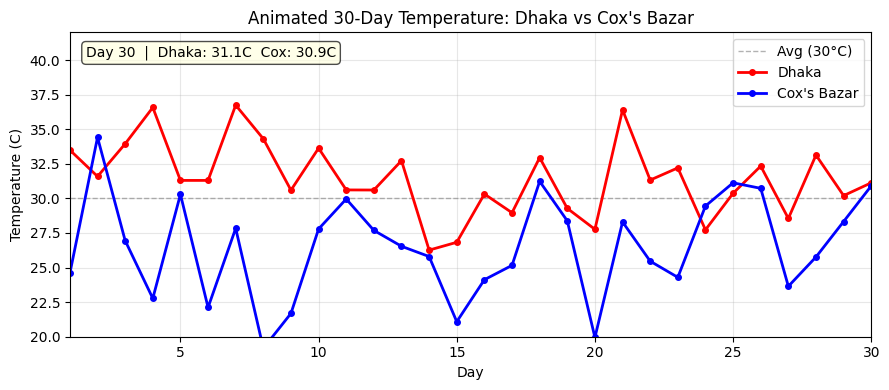

In [ ]:
# --- Animation ---
fig, ax = plt.subplots(figsize=(9, 4))

ax.set_xlim(1, 30)
ax.set_ylim(20, 42)
ax.set_xlabel("Day")
ax.set_ylabel("Temperature (C)")
ax.set_title("Animated 30-Day Temperature: Dhaka vs Cox's Bazar")
ax.axhline(y=30, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Avg (30°C)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

line_d, = ax.plot([], [], 'r-o', markersize=4, linewidth=2, label='Dhaka')
line_c, = ax.plot([], [], 'b-o', markersize=4, linewidth=2, label="Cox's Bazar")
info    = ax.text(0.02, 0.92, '', transform=ax.transAxes, fontsize=10,
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.legend()

def animate(i):
    if i == 0:
        line_d.set_data([], [])
        line_c.set_data([], [])
        info.set_text('')
    else:
        line_d.set_data(days[:i], dhaka[:i])
        line_c.set_data(days[:i], coxsbazar[:i])
        info.set_text("Day {}  |  Dhaka: {:.1f}C  Cox: {:.1f}C".format(
            days[i-1], dhaka[i-1], coxsbazar[i-1]))
    return line_d, line_c, info

ani = animation.FuncAnimation(fig, animate, frames=31,
                               interval=200, blit=True, repeat=False)
plt.tight_layout()
HTML(ani.to_jshtml())

---
## Summary

| Test | Question | Result |
|------|----------|--------|
| One-Sample t-Test | Is Dhaka hotter than national avg (30°C)? | Based on p-value |
| Two-Sample t-Test | Is Dhaka hotter than Cox's Bazar? | Based on p-value |
| Chi-Square Test | Are Cool/Warm/Hot days evenly spread? | Based on chi-stat |
| Animation | How does temp change over 30 days? | Visual answer |
